# Short-Volatility Carry on SPY

A reproducible walkthrough of the project's two deliverables, re-rendered from committed, ToS-clean artifacts (public VIX/VIXY/SPY-derived only), so it runs without any licensed data.

1. **[`STRATEGY.md`](../STRATEGY.md)**, a short-volatility variance-risk-premium carry: short VIXY only while the VIX term structure is in contango. The flagship deliverable.
2. **[`FINDINGS.md`](../FINDINGS.md)**, the signal investigation behind one candidate input: does dealer gamma carry volatility information beyond VIX? (Mostly not, with a small real increment.)

The strategy comes first, then the signal study that explains why one of its inputs earns its place and another does not.

In [1]:
%matplotlib inline
import json
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import Image, display

REPO = Path.cwd()
while not (REPO / "STRATEGY.md").exists() and REPO != REPO.parent:
    REPO = REPO.parent

R = json.load(open(REPO / "analysis/strategy_results.json"))
curves = pd.read_csv(REPO / "analysis/strategy_curves.csv", parse_dates=["date"])
print("window", R["window"], "| n", R["n"], "trading days")

window ['2011-07-28', '2026-05-29'] | n 3731 trading days


## Part A. The strategy: short VIXY only in contango

Index options are structurally expensive. Investors pay up for crash protection they will not sell, so implied volatility prints above realized and the VIX futures curve sits in contango, each contract rolling down toward a lower spot as it nears expiry. Selling that curve collects the implied-vs-realized gap and the roll-down together, which is the variance risk premium. The risk is the left tail: one spike hands back years of carry in days, so the position is held only while the curve is sloped in its favor.

**Rule (no tuned parameter):** short a fixed, modest notional of VIXY whenever `VIX < VIX3M` (term structure in contango), flat otherwise. Signals from the prior close, P&L close-to-close, net of 10 bps turnover and a borrow fee. The table below is quoted against SPY both excess-of-rf and total-return.

In [2]:
H = R["headline_metrics"]; B = R["benchmarks"]
tbl = pd.DataFrame({
    "Contango carry": [H["sharpe"], H["sortino"], H["calmar"], H["cagr"], H["ann_vol"], H["maxdd"]],
    "SPY (excess)":   [B["buy-hold SPY (excess)"]["sharpe"], B["buy-hold SPY (excess)"]["sortino"],
                       B["buy-hold SPY (excess)"]["calmar"], B["buy-hold SPY (excess)"]["cagr"],
                       None, B["buy-hold SPY (excess)"]["maxdd"]],
    "SPY (total ret)":[B["buy-hold SPY (total ret)"]["sharpe"], B["buy-hold SPY (total ret)"]["sortino"],
                       B["buy-hold SPY (total ret)"]["calmar"], B["buy-hold SPY (total ret)"]["cagr"],
                       None, B["buy-hold SPY (total ret)"]["maxdd"]],
}, index=["Sharpe", "Sortino", "Calmar", "CAGR", "Ann vol", "maxDD"]).round(3)
print(tbl.to_string())
print("\nThe carry trails SPY on Sharpe/Sortino and wins on Calmar/maxDD: a drawdown edge, not a Sharpe beat.")

         Contango carry  SPY (excess)  SPY (total ret)
Sharpe            0.744         0.784            0.879
Sortino           0.809         0.962            1.075
Calmar            0.557         0.378            0.433
CAGR              0.085         0.127            0.146
Ann vol           0.119           NaN              NaN
maxDD            -0.153        -0.338           -0.337

The carry trails SPY on Sharpe/Sortino and wins on Calmar/maxDD: a drawdown edge, not a Sharpe beat.


In [3]:
# Reconciliation: recompute the headline from the committed equity curve and assert it matches
# the committed results JSON. The repo's rule is that every quoted number traces to the artifact
# that produced it; this cell proves the two artifacts agree, live, on every notebook run.
eq = curves["carry"].to_numpy()
r = eq / np.concatenate([[1.0], eq[:-1]]) - 1          # full return stream (curve base = 1.0)
sharpe = r.mean() / r.std() * np.sqrt(252)
maxdd = (eq / np.maximum.accumulate(eq) - 1).min()
cagr = eq[-1] ** (252 / len(r)) - 1
assert abs(sharpe - H["sharpe"]) < 1e-6, (sharpe, H["sharpe"])
assert abs(maxdd - H["maxdd"]) < 1e-7, (maxdd, H["maxdd"])
assert abs(cagr - H["cagr"]) < 1e-6, (cagr, H["cagr"])
print(f"reconciled: Sharpe {sharpe:.4f}, maxDD {maxdd:.1%}, CAGR {cagr:.2%}"
      "  (strategy_curves.csv == strategy_results.json)")

reconciled: Sharpe 0.7444, maxDD -15.3%, CAGR 8.51%  (strategy_curves.csv == strategy_results.json)


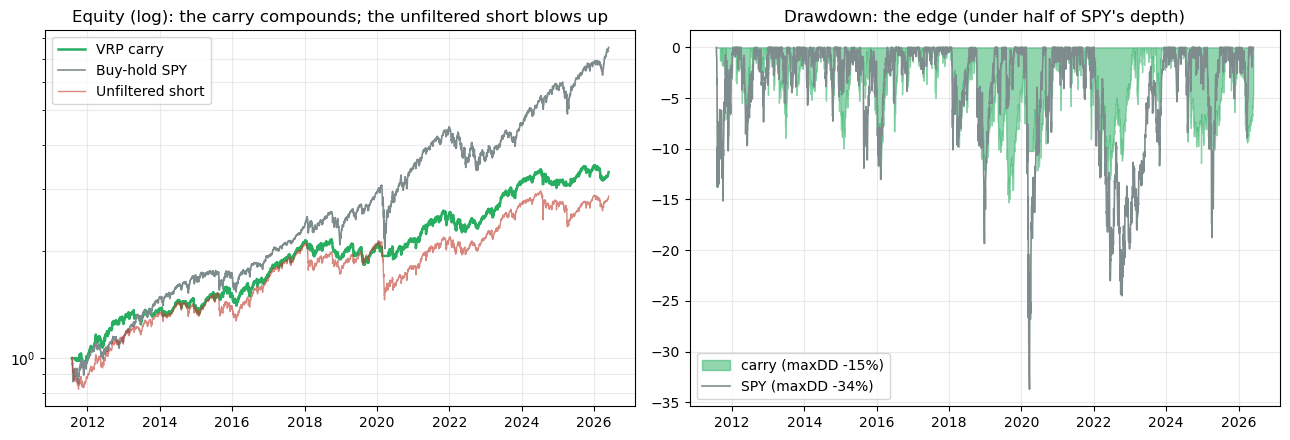

In [4]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.5))
a1.plot(curves["date"], curves["carry"], color="#27ae60", lw=1.8, label="VRP carry")
a1.plot(curves["date"], curves["spy_total"], color="#7f8c8d", lw=1.2, label="Buy-hold SPY")
a1.plot(curves["date"], curves["constant"], color="#c0392b", lw=1.0, alpha=0.6, label="Unfiltered short")
a1.set_yscale("log"); a1.set_title("Equity (log): the carry compounds; the unfiltered short blows up"); a1.legend(); a1.grid(alpha=.25, which="both")
a2.fill_between(curves["date"], curves["carry_dd"]*100, 0, color="#27ae60", alpha=.5, label=f"carry (maxDD {H['maxdd']*100:.0f}%)")
a2.plot(curves["date"], curves["spy_dd"]*100, color="#7f8c8d", lw=1.2, label=f"SPY (maxDD {B['buy-hold SPY (total ret)']['maxdd']*100:.0f}%)")
a2.set_title("Drawdown: the edge (under half of SPY's depth)"); a2.legend(loc="lower left"); a2.grid(alpha=.25)
plt.tight_layout(); plt.show()

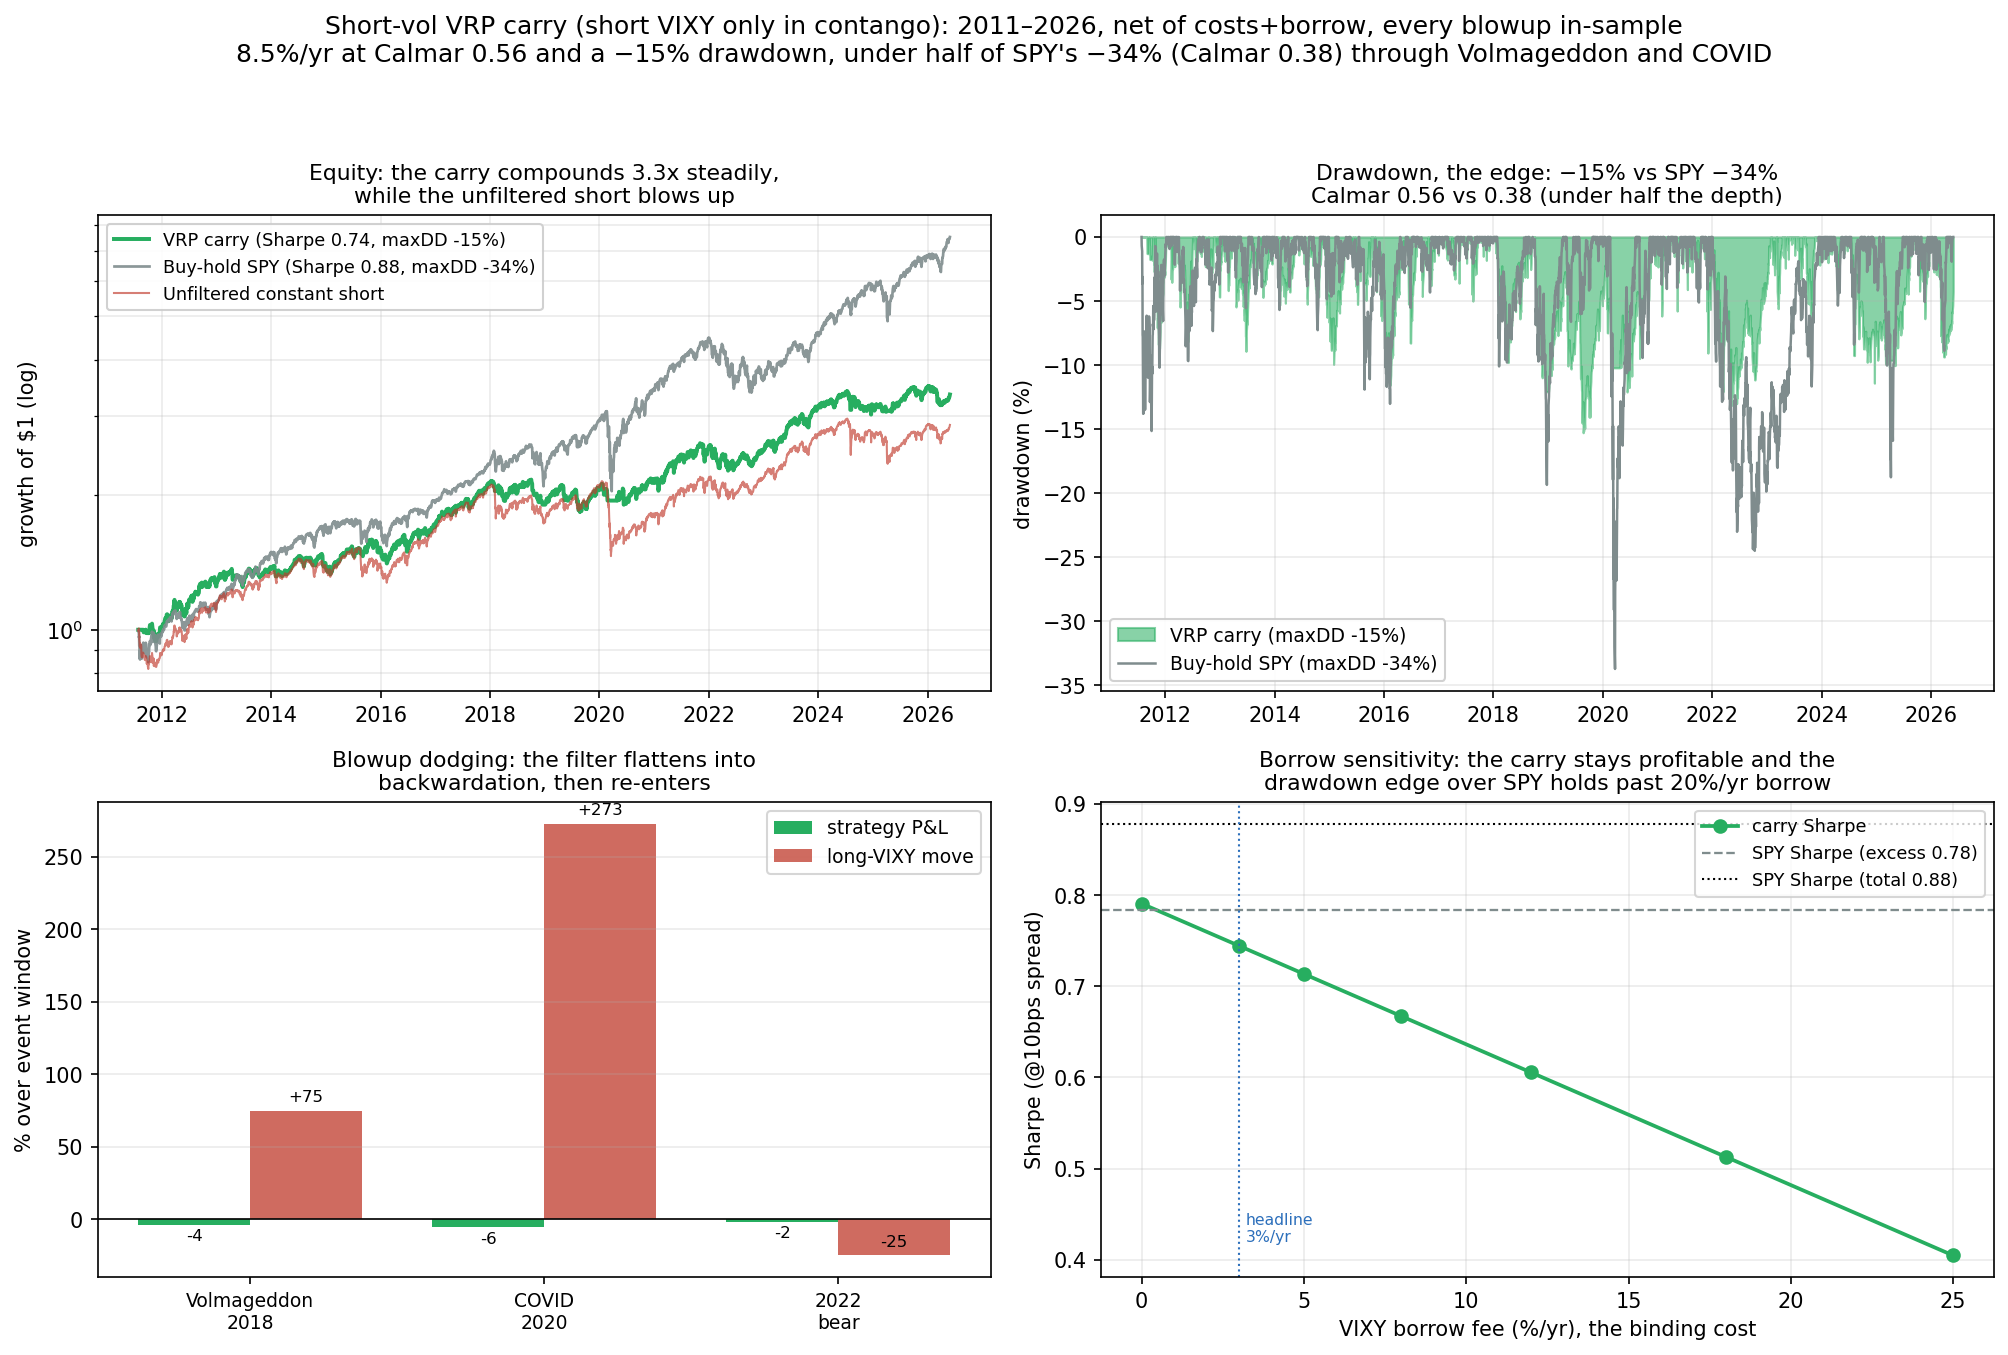

In [5]:
display(Image(filename=str(REPO / "analysis/figures/strategy_headline.png")))

## Reading the result

The carry compounds 3.3x over the window on under half of SPY's drawdown, and its profile is specific:

- **The edge is drawdown control.** Calmar 0.56 vs SPY 0.38, maxDD −15% vs −34%. On Sharpe and Sortino it runs just behind buy-and-hold SPY, which is the more efficient pure return engine; the carry is the more capital-efficient way to hold the premium that equities also pay.
- **Deflated Sharpe is a range, not a point** (0.66–0.81 over 22 variants), comfortably clear of the 0.5 selection-aware bar.
- **Per-regime, only pre-2020 is individually significant**, and the edge roughly halves post-2018 but stays positive, so the recent-regime Sharpe (~0.50) is the right forward anchor.

In [6]:
print(f"Deflated Sharpe range : {R['dsr']['range'][0]:.2f} – {R['dsr']['range'][1]:.2f}   (selection-aware, over 22 variants)")
print(f"Bootstrap P(SR<=0)    : {R['bootstrap_ci_vs0'][2]:.3f}  (vs ZERO, no multiplicity adjustment)")
print(f"Timing sleeve OOS AUC : {R['timing_auc']:.3f}  (a coin flip -> null)")
print(f"Carry-SPY correlation : {R['carry_spy_corr']:+.2f}  (equity-like premium, NOT uncorrelated alpha)\n")
print("Per-regime (HAC t-stat):")
for b, m in R["regime"].items():
    sig = "significant" if abs(m["t_hac"]) > 1.96 else "NOT significant"
    print(f"  {b:<9s} Sharpe {m['sharpe']:+.2f}  t_HAC {m['t_hac']:+.2f}  ({sig})")
print("\nOut-of-sample sub-periods (edge halves post-2018 but stays positive):")
for b, m in R["subperiods"].items():
    print(f"  {b:<18s} Sharpe {m['sharpe']:+.2f} (t {m['t_hac']:+.1f})  Calmar {m['calmar']:+.2f}")

Deflated Sharpe range : 0.66 – 0.81   (selection-aware, over 22 variants)
Bootstrap P(SR<=0)    : 0.001  (vs ZERO, no multiplicity adjustment)
Timing sleeve OOS AUC : 0.506  (a coin flip -> null)
Carry-SPY correlation : +0.61  (equity-like premium, NOT uncorrelated alpha)

Per-regime (HAC t-stat):
  pre2020   Sharpe +0.81  t_HAC +2.52  (significant)
  2020-21   Sharpe +0.83  t_HAC +1.42  (NOT significant)
  2022+     Sharpe +0.58  t_HAC +1.36  (NOT significant)

Out-of-sample sub-periods (edge halves post-2018 but stays positive):
  2011-2018          Sharpe +0.82 (t +2.4)  Calmar +0.75
  2019-2026          Sharpe +0.68 (t +2.1)  Calmar +0.60
  2018+ (post-XIV)   Sharpe +0.51 (t +1.6)  Calmar +0.37


## Part B. The signal: is dealer gamma a VIX echo?

Options dealers hedge inventory: long gamma suppresses volatility, short gamma amplifies it. The trap is asking whether gamma beats VIX at forecasting RV, because VIX *is* the market's price of forward variance. The sharp question is whether gamma adds skill *incremental to* a VIX/HAR baseline.

**Result (15 years, multi-regime, out-of-sample, confound-checked):** dealer gamma is **~95% a VIX echo**. On a calm 21-month window it is a clean null; on deep history it carries a **small but statistically robust gamma-specific increment** (Diebold-Mariano on CRPS *p* = 0.001; it is gamma, not the DIX flow signal, and it survives a richer VIX baseline). Economically marginal, which is why it adds nothing to the trading overlay in Part A.

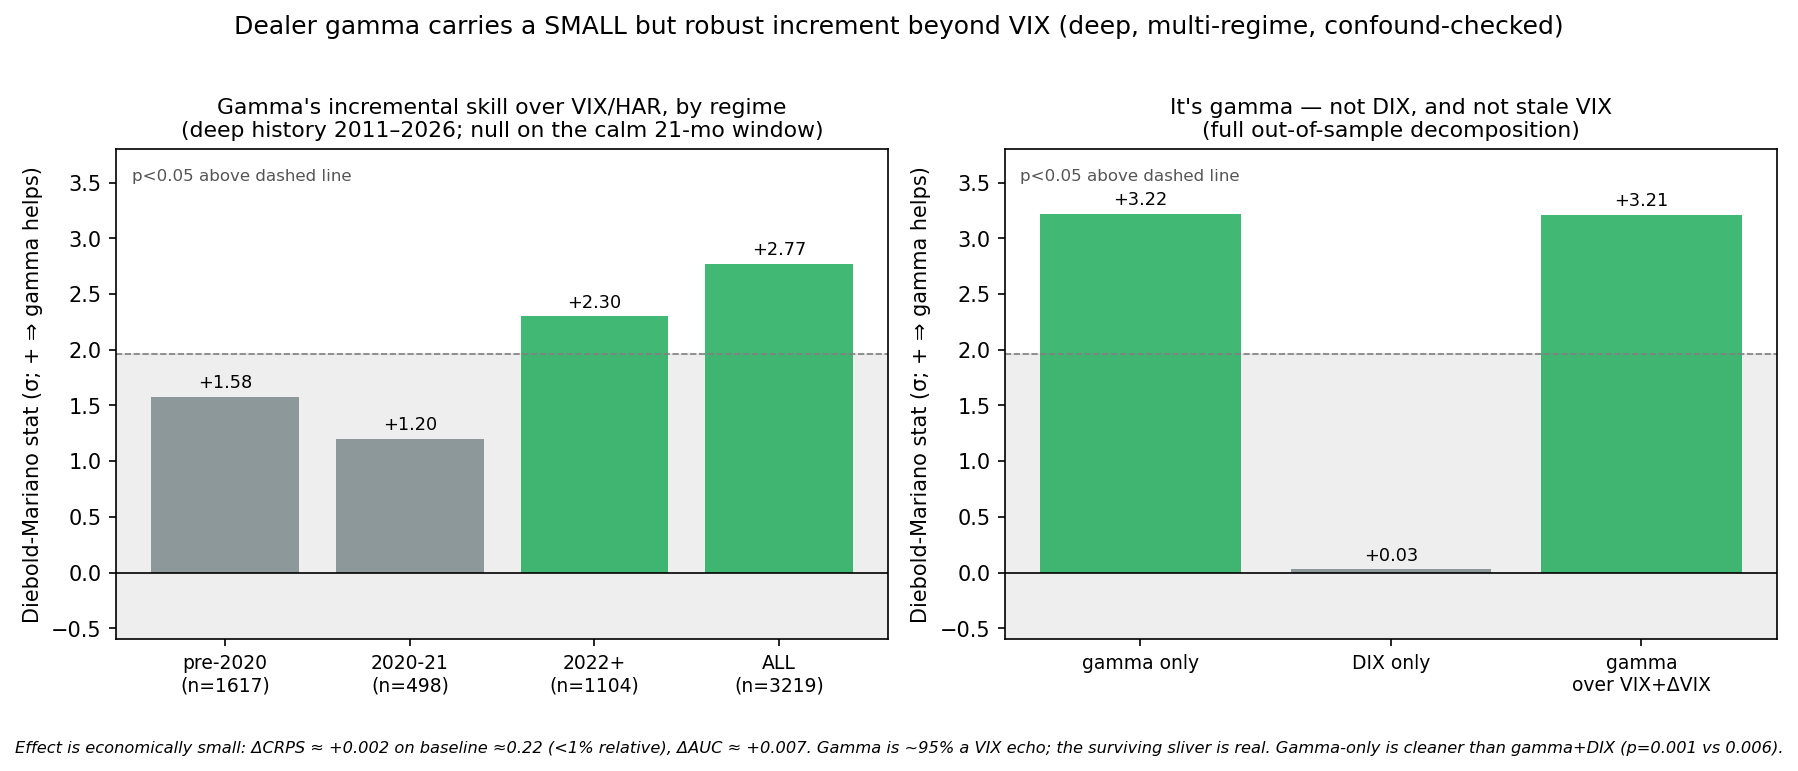

In [7]:
display(Image(filename=str(REPO / "analysis/figures/deep_history_result.png")))

## Where this goes next

The three highest-value free-data upgrades all attack the *drawdown*, the strategy's actual edge, rather than chasing a Sharpe it structurally cannot win: continuous roll/slope-scaled sizing, forward-VRP conditioning (model-free IV minus a Yang-Zhang RV forecast), and a convex left-tail floor. The dead-ends are named in [`STRATEGY.md`](../STRATEGY.md) §7: gamma/DIX timing, naive vol-targeting, and fixed roll thresholds.

**Reproduce:** `python analysis/strategy_two_sleeve.py` then `python analysis/make_figure_strategy.py` (needs the free-data fetchers). This notebook itself re-runs from the committed `strategy_results.json` and `strategy_curves.csv` alone.